In [1]:
import torch
from torch import Tensor, nn
from math import ceil
from torch.autograd import Function
import os
from torch.autograd.function import Function
import triton
from copy import deepcopy
import triton.language as tl

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [2]:

def get_cuda_autotune_config():
    return [
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        # Good config for fp8 inputs.
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
        #               num_warps=8),
        # triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
        #               num_warps=8),
        # triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        # Push Blackwell/B200 TC pipes
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 8},
            num_stages=5, num_warps=16
        ),
    ]




In [3]:
def validate_contiguous(x: Tensor) -> Tensor:
    return x if x.is_contiguous() else x.contiguous()


In [4]:
from torch import nn, Tensor
import torch
from torch.autograd.function import Function
import triton
import triton.language as tl
from math import ceil

import math


@triton.jit()
def _compute_sigma(x):
    return 1 / (1 + tl.exp(-x))

@triton.jit()
def _silu_op_fwd(x):
    return x * _compute_sigma(x)

@triton.jit()
def _silu_op_bwd(x, grad_output):
    sigma = _compute_sigma(x)
    act_prime = sigma * (1 + x * (1 - sigma))
    return grad_output * act_prime


@triton.jit
def _compute_tanh_phi(x):
    # angle = tl.sqrt(2 / math.pi)  * (x + 0.044715 * x * x * x)
    angle = 0.7978845608028654 * (x + 0.044715 * x * x * x)
    exp = tl.exp(2 * angle)
    tanh = (exp - 1) / (exp + 1)
    phi = 0.5 * (1 + tanh)
    return tanh, phi


@triton.jit()
def _gelu_op_fwd(x):
    _, phi = _compute_tanh_phi(x)
    return x * phi


@triton.jit()
def _gelu_op_bwd(x, grad_output):
    tanh, phi = _compute_tanh_phi(x)

    factor = 1 / tl.sqrt(2 * math.pi)
    phi_prime = factor * (1 - tanh * tanh) * (1 + 3 * 0.044715 * x * x)

    derivative = x * phi_prime + phi
    return derivative * grad_output

In [5]:

from math import ceil
import triton
import triton.language as tl
import torch
from torch import nn, Tensor
from torch.autograd import Function

MAP_ACTIVATIONS_FWD = {"gelu": None, "silu": _silu_op_fwd}
MAP_ACTIVATIONS_BWD = {"gelu": None, "silu": _silu_op_bwd}

@triton.jit()
def _activation_fwd(x, activation_name: tl.constexpr):
    if activation_name == "silu":
        return _silu_op_fwd(x)
    elif activation_name == "gelu":
        return _gelu_op_fwd(x)
    else:
        raise NotImplementedError
    # return MAP_ACTIVATIONS_FWD[activation_name](x)


@triton.jit()
def _activation_bwd(x, grad_output, activation_name: tl.constexpr):
    if activation_name == "silu":
        return _silu_op_bwd(x, grad_output)
    elif activation_name == "gelu":
        return _gelu_op_bwd(x, grad_output)
    else:
        raise NotImplementedError

@triton.autotune(
    configs=get_cuda_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit()
def _linear_act_fwd_triton(
    x_ptr,
    w_ptr,
    b_ptr,
    o_ptr,
    M,
    N,
    K,
    stride_xm,
    stride_xk,
    stride_wk,
    stride_wn,
    stride_bn,
    stride_om,
    stride_on,
    activation_name: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    ### map pid to (pid_m, pid_n)
    pid_m = pid // num_programs_n
    pid_n = pid % num_programs_n

    ### get offsets along M, N, K directions
    offset_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offset_k = tl.arange(0, BLOCK_SIZE_K)

    mask_m = offset_m[:, None] < M
    mask_n = offset_n[None, :] < N

    ### get starting pointers for x, w, b
    tile_x_ptr = x_ptr + (offset_m[:, None] * stride_xm + offset_k[None, :] * stride_xk)
    tile_w_ptr = w_ptr + (offset_k[:, None] * stride_wk + offset_n[None, :] * stride_wn)
    tile_b_ptr = b_ptr + offset_n[None, :] * stride_bn

    tile_b = tl.load(tile_b_ptr, mask_n, other=0.0)

    ### frist compute z = x @ W.T + b
    z = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # mask values depending on k: note that we are not loading all the row
        # up to k * BLOCK_SIZE_K. Since we are advancing the pointers
        # (see tile_x_ptr += ..., tile_w_ptr += ...) we are considering only
        # the portion [k*BLOCK_SIZE_K:(k+1)*BLOCK_SIZE_K].
        mask_k = offset_k < K - k * BLOCK_SIZE_K

        tile_x = tl.load(tile_x_ptr, mask_k[None, :], other=0.0)
        tile_w = tl.load(tile_w_ptr, mask_k[:, None], other=0.0)

        z = tl.dot(tile_x, tile_w, z)

        # advance the pointers along k directions to the next block
        tile_x_ptr += BLOCK_SIZE_K * stride_xk
        tile_w_ptr += BLOCK_SIZE_K * stride_wk

    ### then compute activation + downcast to bfloat16
    # z += tile_b
    # o = z
    o = _activation_fwd(z + tile_b, activation_name)
    # o = o.to(tl.bfloat16)

    tile_o_ptr = o_ptr + offset_m[:, None] * stride_om + offset_n[None, :] * stride_on
    mask_o = mask_m & mask_n
    tl.store(tile_o_ptr, o, mask_o)


def _linear_act_fwd(
    x: Tensor,
    W: Tensor,
    b: Tensor,
    transpose_x: bool = False,
    transpose_W: bool = False,
    activation_name: str = "gelu",
):
    """
    Triton implementation of the following kernel
        z = x @ W.T + b
        out =  f(z)

    IMPORTANT NOTE: the .T operation is done inside tge triton kernel by swapping the
    stride values of W, therefore pass W and not W.T.

    """
    assert x.ndim == 2, "expected A to have ndim=2"
    assert W.ndim == 2, "expected B to have ndim=2"

    if transpose_x:
        M, K = x.shape
        raise NotImplementedError
    else:
        K, M = x.shape
        
    if transpose_W:
        N = W.shape[0]
        assert K == W.shape[1], "dimension mismatch"
        stride_W = (W.stride(1), W.stride(0))
    else:
        N = W.shape[0]
        stride_W = (W.stride(0), W.stride(1))
        assert K == W.shape[0], "dimension mismatch"

    assert b.ndim <= 1, f"b is expected to be either 0D or 1D tensor, got {b.ndim}D"
    # assert b.shape[0] == W.shape[1], "dimension mismatch"

    if b.ndim == 0:
        b = b.view(1, -1)

    # using naive block matmul for now, implement more efficient algo later

    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K = (64, 64, 64)  # hard-coded for now
    # GROUP_SIZE_M = 8
    # grid = ((ceil(M / BLOCK_SIZE_M) * ceil(N / BLOCK_SIZE_N)),)

    out = torch.zeros((M, N), device=x.device, dtype=x.dtype)

    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    _linear_act_fwd_triton[grid](
        x,
        W,
        b,
        out,
        M,
        N,
        K,
        x.stride(0),
        x.stride(1),
        stride_W[0],
        stride_W[1],
        b.stride(0),
        out.stride(0),
        out.stride(1),
        activation_name,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
    )
    ...

    return out.to(x.dtype)



tensor(0.0030, device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)


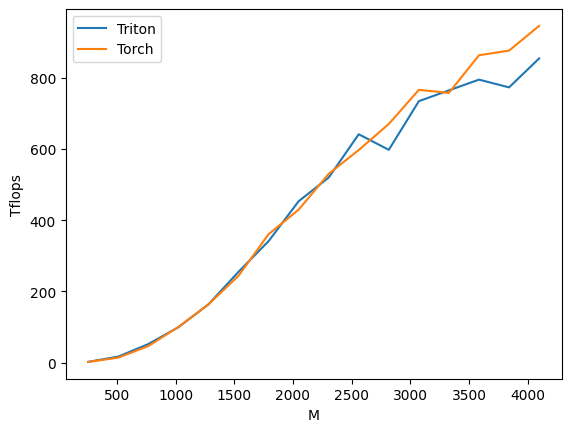

softmax - flops - fwd:
         M       N       K      Triton       Torch
0    256.0   256.0   256.0    2.016492    1.829976
1    512.0   512.0   512.0   16.777215   13.774398
2    768.0   768.0   768.0   52.043293   46.412381
3   1024.0  1024.0  1024.0   99.273464   99.864382
4   1280.0  1280.0  1280.0  163.635458  163.635458
5   1536.0  1536.0  1536.0  255.059024  243.802393
6   1792.0  1792.0  1792.0  341.234887  360.743790
7   2048.0  2048.0  2048.0  453.438251  429.840614
8   2304.0  2304.0  2304.0  520.008092  530.473205
9   2560.0  2560.0  2560.0  641.723384  597.479211
10  2816.0  2816.0  2816.0  597.966842  670.665376
11  3072.0  3072.0  3072.0  734.768608  766.471773
12  3328.0  3328.0  3328.0  765.101756  758.052453
13  3584.0  3584.0  3584.0  795.271554  863.792422
14  3840.0  3840.0  3840.0  773.539648  876.844401
15  4096.0  4096.0  4096.0  854.719886  946.236488
tensor(0.0030, device='cuda:0', dtype=torch.bfloat16)
tensor(0., device='cuda:0', dtype=torch.bfloat16)
tensor

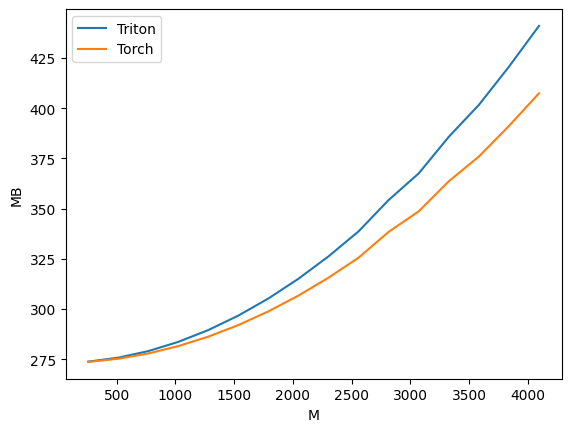

softmax - memory - fwd:
         M       N       K      Triton       Torch
0    256.0   256.0   256.0  273.810432  273.679360
1    512.0   512.0   512.0  275.777024  275.252736
2    768.0   768.0   768.0  279.054336  277.874688
3   1024.0  1024.0  1024.0  283.642368  281.545216
4   1280.0  1280.0  1280.0  289.541120  286.264320
5   1536.0  1536.0  1536.0  296.750592  292.032000
6   1792.0  1792.0  1792.0  305.270784  298.848256
7   2048.0  2048.0  2048.0  315.101696  306.713088
8   2304.0  2304.0  2304.0  326.243328  315.626496
9   2560.0  2560.0  2560.0  338.695680  325.588480
10  2816.0  2816.0  2816.0  354.293760  338.434048
11  3072.0  3072.0  3072.0  367.532544  348.658176
12  3328.0  3328.0  3328.0  385.752064  363.600896
13  3584.0  3584.0  3584.0  401.612288  375.922176
14  3840.0  3840.0  3840.0  420.618240  391.127040
15  4096.0  4096.0  4096.0  440.934912  407.380480


In [7]:
def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

base_benchmark_kwargs = {
        "x_names":['M', 'N', "K"],  # argument names to use as an x-axis for the plot
        "x_vals":[128 * i for i in range(2, 33, 2)],  # different possible values for `x_name`
        "line_arg":'provider',  # argument name whose value corresponds to a different line in the plot
        "line_vals":['triton', 'torch'],  # possible values for `line_arg``
        "line_names":["Triton", "Torch"],  # label name for the lines
        # "styles":[('blue', '-'), ('green', '-')],  # line styles
        "ylabel":"GB/s",  # label name for the y-axis
        "plot_name":"softmax",  # name for the plot. Used also as a file name for saving the plot.
        "args":{}, #{'K': 256} # values for function arguments not in `x_names` and `y_name`
}

from copy import deepcopy
configs = []
for bench_kind in ['flops', 'memory']:
    for mode in ['fwd']: #, 'bwd']:
        _kwargs = deepcopy(base_benchmark_kwargs)
        _kwargs['args'].update({"mode" : mode})
        _kwargs['args'].update({"bench_kind" : bench_kind})
        _kwargs['ylabel'] = 'Tflops' if bench_kind == 'flops' else 'MB'
        _kwargs['plot_name'] += f' - {bench_kind} - {mode}'
        configs.append(triton.testing.Benchmark(**_kwargs))


def fwd(x, W, b, provider):
    if provider == "torch":
        return torch.nn.functional.silu(x @ W.T + b)
    elif provider == 'triton':
        return _linear_act_fwd(x, W, b, transpose_W=True)
    else:
        raise ValueError

def bwd(x, provider):
    x.requires_grad = True
    out = fwd(x, provider)
    loss = out.sum()
    loss.backward()

MAP_FWD_BKW = {
    "fwd" : fwd,
    # "bwd" : bwd,
}

def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

# torch.set_float32_matmul_precision("medium")
# torch.backends.cudnn.conv.fp32_precision = 'tf32'


def benchmark_kernel():

    # for c in configs:
    #     print(c.__dict__)

    @triton.testing.perf_report(configs)
    def benchmark(M, N, K, provider, mode, bench_kind):
        
        # print(M, N, K, provider, mode, bench_kind)
        DTYPE = torch.bfloat16
        
        x = torch.rand(M, K, dtype=DTYPE).to(DEVICE) / M / K
        W = torch.rand(K, N, dtype=DTYPE).to(DEVICE) / K / N
        b = torch.rand(N, dtype=DTYPE).to(DEVICE) / N

        W = W.T

        stream = getattr(torch, DEVICE.type).Stream()
        getattr(torch, DEVICE.type).set_stream(stream)

        if provider == 'triton' and mode =="fwd":
            out_triton = MAP_FWD_BKW[mode](x, W, b, 'triton')
            out_torch = MAP_FWD_BKW[mode](x, W, b, 'torch')
            triton.testing.assert_close(out_triton, out_torch, atol=1e-5)
            print((out_triton - out_torch).norm()/out_torch.norm())

        quantiles = [0.5, 0.2, 0.8]

        if bench_kind == "flops":
            ms, min_ms, max_ms = triton.testing.do_bench(lambda: MAP_FWD_BKW[mode](x, W, b, provider), quantiles=quantiles)
            # gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
            perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
            return perf(ms)
        elif bench_kind == "memory":
            mem_mb = measure_memory(MAP_FWD_BKW[mode], x, W, b, provider)
            return mem_mb
        raise ValueError(f"bench_kind must be either 'flops' or 'memory', got {bench_kind}")

    result_dfs = benchmark.run(show_plots=True, print_data=True)
    # for df, config in zip(result_dfs, configs):
    #     df.plot(x='N', ylabel = config.ylabel, title=config.plot_name, legend=True)

    return result_dfs

result_dfs = benchmark_kernel()

In [8]:

@triton.jit()
def _linear_act_fwd_triton(
    x_ptr,
    w_ptr,
    b_ptr,
    o_ptr,
    M,
    N,
    K,
    stride_xm,
    stride_xk,
    stride_wk,
    stride_wn,
    stride_bn,
    stride_om,
    stride_on,
    # activation_name,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    ### map pid to (pid_m, pid_n)
    pid_m = pid // num_programs_n
    pid_n = pid % num_programs_n

    ### get offsets along M, N, K directions
    offset_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offset_k = tl.arange(0, BLOCK_SIZE_K)

    mask_m = offset_m[:, None] < M
    mask_n = offset_n[None, :] < N

    ### get starting pointers for x, w, b
    tile_x_ptr = x_ptr + (offset_m[:, None] * stride_xm + offset_k[None, :] * stride_xk)
    tile_w_ptr = w_ptr + (offset_k[:, None] * stride_wk + offset_n[None, :] * stride_wn)
    tile_b_ptr = b_ptr + offset_n[None, :] * stride_bn

    tile_b = tl.load(tile_b_ptr, mask_n, other=0.0)

    ### frist compute z = x @ W.T + b
    z = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # mask values depending on k: note that we are not loading all the row
        # up to k * BLOCK_SIZE_K. Since we are advancing the pointers
        # (see tile_x_ptr += ..., tile_w_ptr += ...) we are considering only
        # the portion [k*BLOCK_SIZE_K:(k+1)*BLOCK_SIZE_K].
        mask_k = offset_k < K - k * BLOCK_SIZE_K

        tile_x = tl.load(tile_x_ptr, mask_k[None, :], other=0.0)
        tile_w = tl.load(tile_w_ptr, mask_k[:, None], other=0.0)

        z = tl.dot(tile_x, tile_w, z)

        # advance the pointers along k directions to the next block
        tile_x_ptr += BLOCK_SIZE_K * stride_xk
        tile_w_ptr += BLOCK_SIZE_K * stride_wk

    ### then compute activation + downcast to bfloat16
    z += tile_b
    # o = z
    o = _gelu_op_fwd(z)
    # o = o.to(tl.bfloat16)

    tile_o_ptr = o_ptr + offset_m[:, None] * stride_om + offset_n[None, :] * stride_on
    mask_o = mask_m & mask_n
    tl.store(tile_o_ptr, o, mask_o)


def _linear_act_fwd(
    x: Tensor,
    W: Tensor,
    b: Tensor,
    transpose_x: bool = False,
    transpose_W: bool = False,
    activation_name: str = "gelu",
):
    """
    Triton implementation of the following kernel
        z = x @ W.T + b
        out =  f(z)

    IMPORTANT NOTE: the .T operation is done inside tge triton kernel by swapping the
    stride values of W, therefore pass W and not W.T.

    """
    assert x.ndim == 2, "expected A to have ndim=2"
    assert W.ndim == 2, "expected B to have ndim=2"

    if transpose_x:
        M, K = x.shape
        raise NotImplementedError
    else:
        K, M = x.shape
        
    if transpose_W:
        N = W.shape[0]
        assert K == W.shape[1], "dimension mismatch"
        stride_W = (W.stride(1), W.stride(0))
    else:
        N = W.shape[0]
        stride_W = (W.stride(0), W.stride(1))
        assert K == W.shape[0], "dimension mismatch"

    assert b.ndim <= 1, f"b is expected to be either 0D or 1D tensor, got {b.ndim}D"
    # assert b.shape[0] == W.shape[1], "dimension mismatch"

    if b.ndim == 0:
        b = b.view(1, -1)

    # using naive block matmul for now, implement more efficient algo later

    BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K = (64, 64, 64)  # hard-coded for now
    GROUP_SIZE_M = 8

    grid = ((ceil(M / BLOCK_SIZE_M) * ceil(N / BLOCK_SIZE_N)),)

    out = torch.zeros((M, N)).to(x.device)

    _linear_act_fwd_triton[grid](
        x,
        W,
        b,
        out,
        M,
        N,
        K,
        x.stride(0),
        x.stride(1),
        stride_W[0],
        stride_W[1],
        b.stride(0),
        out.stride(0),
        out.stride(1),
        # activation_name,
        BLOCK_SIZE_M,
        BLOCK_SIZE_N,
        BLOCK_SIZE_K,
        GROUP_SIZE_M,
    )
    ...

    return out



32 32 32 triton fwd flops
32 32 32 torch fwd flops


288 288 288 triton fwd flops
288 288 288 torch fwd flops
544 544 544 triton fwd flops
544 544 544 torch fwd flops
800 800 800 triton fwd flops
800 800 800 torch fwd flops
1056 1056 1056 triton fwd flops
1056 1056 1056 torch fwd flops
1312 1312 1312 triton fwd flops
1312 1312 1312 torch fwd flops
1568 1568 1568 triton fwd flops
1568 1568 1568 torch fwd flops
1824 1824 1824 triton fwd flops
1824 1824 1824 torch fwd flops
2080 2080 2080 triton fwd flops
2080 2080 2080 torch fwd flops
2336 2336 2336 triton fwd flops
2336 2336 2336 torch fwd flops
2592 2592 2592 triton fwd flops
2592 2592 2592 torch fwd flops
2848 2848 2848 triton fwd flops
2848 2848 2848 torch fwd flops
3104 3104 3104 triton fwd flops
3104 3104 3104 torch fwd flops
3360 3360 3360 triton fwd flops
3360 3360 3360 torch fwd flops
3616 3616 3616 triton fwd flops
3616 3616 3616 torch fwd flops
3872 3872 3872 triton fwd flops
3872 3872 3872 torch fwd flops


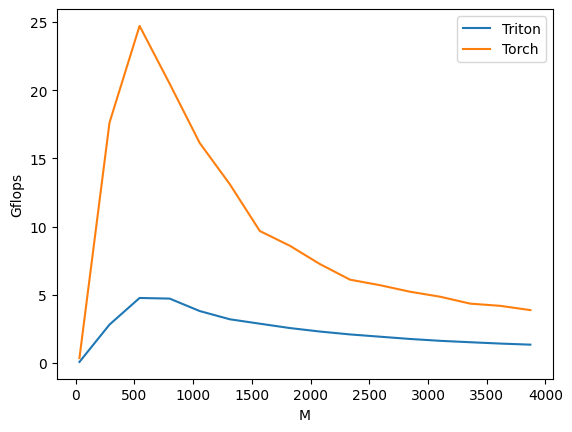

softmax - flops - fwd:
         M       N       K    Triton      Torch
0     32.0    32.0    32.0  0.072130   0.352912
1    288.0   288.0   288.0  2.809504  17.621415
2    544.0   544.0   544.0  4.761742  24.709414
3    800.0   800.0   800.0  4.715575  20.476881
4   1056.0  1056.0  1056.0  3.803490  16.127298
5   1312.0  1312.0  1312.0  3.200406  13.108264
6   1568.0  1568.0  1568.0  2.874828   9.671488
7   1824.0  1824.0  1824.0  2.555546   8.589087
8   2080.0  2080.0  2080.0  2.299682   7.247415
9   2336.0  2336.0  2336.0  2.088475   6.103644
10  2592.0  2592.0  2592.0  1.921209   5.696822
11  2848.0  2848.0  2848.0  1.755259   5.217744
12  3104.0  3104.0  3104.0  1.618670   4.852865
13  3360.0  3360.0  3360.0  1.515258   4.345630
14  3616.0  3616.0  3616.0  1.417951   4.184457
15  3872.0  3872.0  3872.0  1.337811   3.871149
32 32 32 triton fwd memory
32 32 32 torch fwd memory
288 288 288 triton fwd memory
288 288 288 torch fwd memory
544 544 544 triton fwd memory
544 544 544 torch f

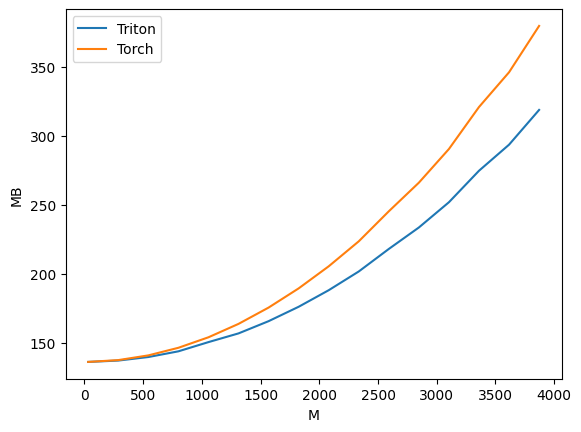

softmax - memory - fwd:
         M       N       K      Triton       Torch
0     32.0    32.0    32.0  136.349184  136.353280
1    288.0   288.0   288.0  137.333248  137.665024
2    544.0   544.0   544.0  139.890176  141.073920
3    800.0   800.0   800.0  144.019968  146.579968
4   1056.0  1056.0  1056.0  150.693376  154.183168
5   1312.0  1312.0  1312.0  156.998144  163.883520
6   1568.0  1568.0  1568.0  165.846528  175.681024
7   1824.0  1824.0  1824.0  176.267776  189.575680
8   2080.0  2080.0  2080.0  188.261888  205.567488
9   2336.0  2336.0  2336.0  201.828864  223.656448
10  2592.0  2592.0  2592.0  218.136064  245.399040
11  2848.0  2848.0  2848.0  233.681408  266.125824
12  3104.0  3104.0  3104.0  251.966976  290.506240
13  3360.0  3360.0  3360.0  274.762240  320.899584
14  3616.0  3616.0  3616.0  293.637632  346.066432
15  3872.0  3872.0  3872.0  318.804480  379.621888


In [ ]:
def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

base_benchmark_kwargs = {
        "x_names":['M', 'N', "K"],  # argument names to use as an x-axis for the plot
        "x_vals":[16 * i for i in range(2, 256, 16)],  # different possible values for `x_name`
        "line_arg":'provider',  # argument name whose value corresponds to a different line in the plot
        "line_vals":['triton', 'torch'],  # possible values for `line_arg``
        "line_names":["Triton", "Torch"],  # label name for the lines
        # "styles":[('blue', '-'), ('green', '-')],  # line styles
        "ylabel":"GB/s",  # label name for the y-axis
        "plot_name":"softmax",  # name for the plot. Used also as a file name for saving the plot.
        "args":{}, #{'K': 256} # values for function arguments not in `x_names` and `y_name`
}

from copy import deepcopy
configs = []
for bench_kind in ['flops', 'memory']:
    for mode in ['fwd']: #, 'bwd']:
        _kwargs = deepcopy(base_benchmark_kwargs)
        _kwargs['args'].update({"mode" : mode})
        _kwargs['args'].update({"bench_kind" : bench_kind})
        _kwargs['ylabel'] = 'Gflops' if bench_kind == 'flops' else 'MB'
        _kwargs['plot_name'] += f' - {bench_kind} - {mode}'
        configs.append(triton.testing.Benchmark(**_kwargs))


def fwd(x, W, b, provider):
    if provider == "torch":
        return torch.nn.functional.gelu(x @ W.T + b)
    elif provider == 'triton':
        return _linear_act_fwd(x, W.T, b, transpose_W=False)
    else:
        raise ValueError

def bwd(x, provider):
    x.requires_grad = True
    out = fwd(x, provider)
    loss = out.sum()
    loss.backward()

MAP_FWD_BKW = {
    "fwd" : fwd,
    # "bwd" : bwd,
}

def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

def benchmark_kernel():

    # for c in configs:
    #     print(c.__dict__)

    @triton.testing.perf_report(configs)
    def benchmark(M, N, K, provider, mode, bench_kind):
        
        print(M, N, K, provider, mode, bench_kind)
        
        x = torch.rand(M, K).to(DEVICE) / M / K
        W = torch.rand(N, K).to(DEVICE) / K / N
        b = torch.rand(N).to(DEVICE) / N
    
        stream = getattr(torch, DEVICE.type).Stream()
        getattr(torch, DEVICE.type).set_stream(stream)
        if bench_kind == "flops":
            ms = triton.testing.do_bench(lambda: MAP_FWD_BKW[mode](x, W, b, provider))
            perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
            # gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
            return perf(ms)
        elif bench_kind == "memory":
            mem_mb = measure_memory(MAP_FWD_BKW[mode], x, W, b, provider)
            return mem_mb
        raise ValueError(f"bench_kind must be either 'timing' or 'memory', got {bench_kind}")

    result_dfs = benchmark.run(show_plots=True, print_data=True, return_df=True)
    # for df, config in zip(result_dfs, configs):
    #     df.plot(x='N', ylabel = config.ylabel, title=config.plot_name, legend=True)

    return result_dfs

result_dfs = benchmark_kernel()